<a href="https://colab.research.google.com/github/sandotra1/Physics-Simulation-Collection/blob/main/MagneticResonance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Magnetic Resonance Simulation

This simulation demonstrates the phenomenon of magnetic resonance, specifically the precession of a magnetization vector in the presence of a constant magnetic field.


### Simulation Overview:
- First, we demonstrate how the magnetization vector starts aligned with the x-axis, and as time progresses, it begins to precess around the z-axis under the influence of the magnetic field.
- The path of the magnetization is traced, and you can observe how the vector rotates in the xy-plane.


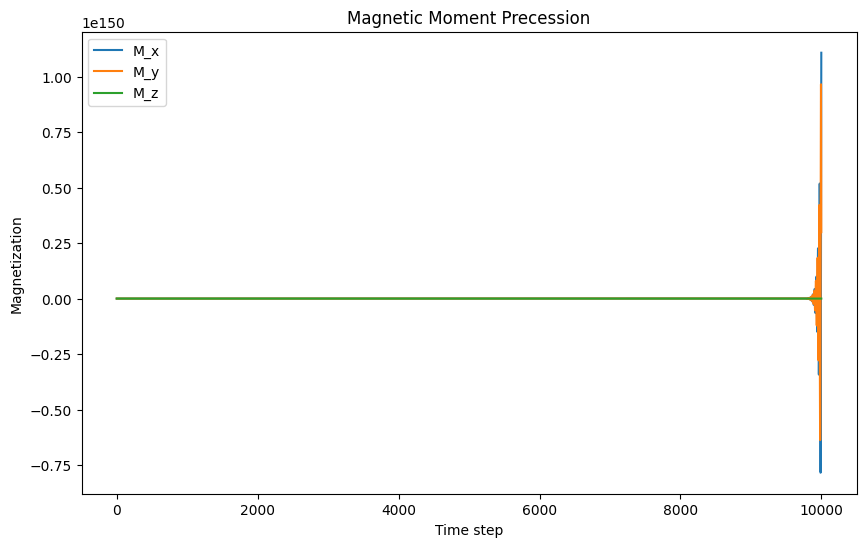

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_magnetic_resonance(M0, B, gamma, dt, steps):
    M = np.zeros((steps, 3))
    M[0] = M0

    for i in range(1, steps):
        dM = gamma * np.cross(M[i-1], B)
        M[i] = M[i-1] + dM * dt

    return M

# Parameters
gamma = 2.675e8
B = np.array([0, 0, 1])
M0 = np.array([1, 0, 0])  # (starting along x-axis)
dt = 1e-9
steps = 10000

M = simulate_magnetic_resonance(M0, B, gamma, dt, steps)


plt.figure(figsize=(10, 6))
plt.plot(M[:, 0], label='M_x')
plt.plot(M[:, 1], label='M_y')
plt.plot(M[:, 2], label='M_z')
plt.xlabel('Time step')
plt.ylabel('Magnetization')
plt.legend()
plt.title('Magnetic Moment Precession')
plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def simulate_magnetic_resonance(M0, B, gamma, dt, steps):
    M = np.zeros((steps, 3))
    M[0] = M0
    for i in range(1, steps):
        dM = gamma * np.cross(M[i-1], B)
        M[i] = M[i-1] + dM * dt
        M[i] /= np.linalg.norm(M[i])
    return M

# Simulation parameters
gamma = 2.675e8
B = np.array([0, 0, 1])
M0 = np.array([1, 0, 0])
dt = 1e-9
steps = 2000


M = simulate_magnetic_resonance(M0, B, gamma, dt, steps)


fig = plt.figure(figsize=(6,6), dpi=80)
ax = fig.add_subplot(111, projection='3d')


ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Magnetization Precession")


point, = ax.plot([], [], [], 'ro', markersize=12, zorder=5)
line, = ax.plot([], [], [], lw=2, color='blue', zorder=1)


ax.quiver(0, 0, 0, B[0], B[1], B[2], color='g', length=0.8, lw=2, label="Magnetic Field B")

def init():
    point.set_data([], [])
    point.set_3d_properties([])
    line.set_data([], [])
    line.set_3d_properties([])
    return point, line

def update(frame):
    current_M = M[:frame+1]

    point.set_data([current_M[-1, 0]], [current_M[-1, 1]])
    point.set_3d_properties([current_M[-1, 2]])

    line.set_data(current_M[:, 0], current_M[:, 1])
    line.set_3d_properties(current_M[:, 2])
    return point, line


ani = FuncAnimation(fig, update, frames=range(0, steps, 50),
                    init_func=init, interval=100)

plt.close(fig)
HTML(ani.to_jshtml())



